<a href="https://colab.research.google.com/github/Blazingshadows/Agentic-AI-Labs/blob/main/Copy_of_Part_4(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Core Concept: How an RNN Tracks Time

An RNN doesn't need to flatten text dimensions because it contains a mathematical feedback loop.

When an RNN reads the sequence ['l', 'e', 'a']:

    It reads 'l' → combines it with an empty hidden state → creates Hidden State 1.

    It reads 'e' → combines it with Hidden State 1 → creates Hidden State 2.

    It reads 'a' → combines it with Hidden State 2 → creates Hidden State 3.

When predicting the next character, the network evaluates Hidden State 3, which mathematically contains traces of 'l', 'e', and 'a' in their exact chronological order.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Same 500-word dataset
text = """Deep learning is a subset of machine learning, which is essentially a neural network with three or more layers.
These neural networks attempt to simulate the behavior of the human brain though far from matching its ability,
allowing it to learn from large amounts of data. While a neural network with a single layer can still make
approximate predictions, additional hidden layers can help to optimize and refine for accuracy."""

chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# 2. Sequential Window Setup
window_size = 9
X_data = []
Y_data = []

encoded_text = [char_to_int[ch] for ch in text]

for i in range(len(encoded_text) - window_size):
    X_data.append(encoded_text[i : i + window_size])
    Y_data.append(encoded_text[i + window_size])

X_tensor = torch.tensor(X_data, dtype=torch.long)
Y_tensor = torch.tensor(Y_data, dtype=torch.long)

print(f"Dataset Loaded for RNN processing!")
print(f"X Shape: {X_tensor.shape} | Y Shape: {Y_tensor.shape}")

Dataset Loaded for RNN processing!
X Shape: torch.Size([420, 9]) | Y Shape: torch.Size([420])


In [ ]:
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(RNNLanguageModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # The RNN layer processes tokens one by one.
        # It passes an internal 'hidden state' vector forward across time steps.
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)

        # The final Fully Connected layer maps the final hidden state to vocabulary scores
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x shape: [batch_size, window_size]
        embeds = self.embedding(x)  # Shape: [batch_size, window_size, embedding_dim]

        # out contains the hidden states for ALL time steps
        # hidden contains ONLY the absolute last hidden state vector
        out, hidden = self.rnn(embeds)

        # We extract the output of the final step in the sequence
        final_step_output = out[:, -1, :]  # Shape: [batch_size, hidden_size]

        logits = self.fc(final_step_output)
        return logits

# Initialize hyper-parameters matching Assignment 1
EMBED_DIM = 16
HIDDEN_SIZE = 64
model = RNNLanguageModel(vocab_size, EMBED_DIM, HIDDEN_SIZE)
print(model)

RNNLanguageModel(
  (embedding): Embedding(31, 16)
  (rnn): RNN(16, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=31, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
loss_list_rnn = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    predictions = model(X_tensor)
    loss = criterion(predictions, Y_tensor)

    loss.backward()
    optimizer.step()
    loss_list_rnn.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | RNN Loss: {loss.item():.4f}")

Epoch 020/100 | RNN Loss: 1.8174
Epoch 040/100 | RNN Loss: 0.5608
Epoch 060/100 | RNN Loss: 0.0649
Epoch 080/100 | RNN Loss: 0.0242
Epoch 100/100 | RNN Loss: 0.0183


In [ ]:
def generate_text(model, seed_str, length=100):
    model.eval()
    if len(seed_str) != window_size:
        return f"Error: Seed must be exactly {window_size} characters!"

    generated = seed_str
    current_context = [char_to_int[ch] for ch in seed_str]

    with torch.no_grad():
        for _ in range(length):
            input_tensor = torch.tensor([current_context], dtype=torch.long)
            output = model(input_tensor)

            # Select the character with the absolute highest probability score
            predicted_int = torch.argmax(output, dim=1).item()
            generated += int_to_char[predicted_int]

            # Slide window forward: drop index 0, append new character ID
            current_context = current_context[1:] + [predicted_int]

    return generated

print("--- GENERATED TEXT OUTPUT ---")
print(generate_text(model, seed_str="Deep lear", length=150))
print("-----------------------------")

--- GENERATED TEXT OUTPUT ---
Deep learning is a subset of machine learning is a subset of machine learning is a subset of machine learning is a subset of machine learning is a subset of ma
-----------------------------


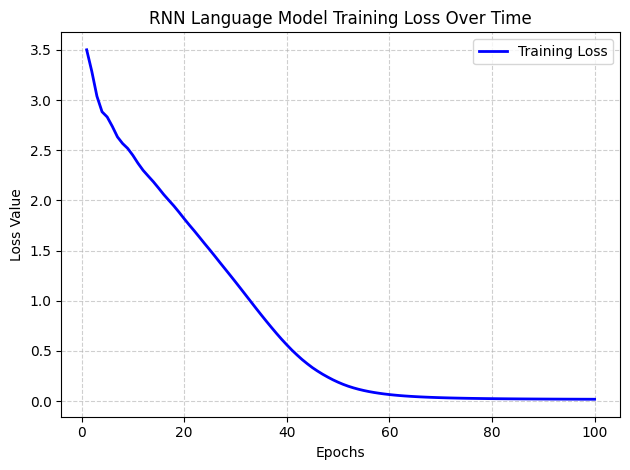

In [ ]:
import matplotlib.pyplot as plt

# Plotting the training loss over epochs
plt.plot(range(1, epochs + 1), loss_list_rnn, label='Training Loss', color='blue', linewidth=2)

# Adding labels and styling
plt.title('RNN Language Model Training Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Display or save the layout
plt.tight_layout()
plt.savefig('loss_curve.png') # Use this to save it as an image file
plt.show()                    # Use this to display it directly inside Google Colab / Jupyter